# Agama BFE coefficients with a time axis

`MultipoleCoefs` and `CylSplineCoefs` hold **either a single snapshot or a whole time
series**, in the same class. Time is always the *last* array axis and is always optional.
There is no separate series reader and no separate series class.

| field | no time axis | with time axis |
|---|---|---|
| `MultipoleCoefs.phi` | `(nR, n_lm)` | `(nR, n_lm, nt)` |
| `MultipoleCoefs.dphi_dr` | `(nR, n_lm)` or `None` | `(nR, n_lm, nt)` or `None` |
| `CylSplineCoefs.phi[m]` | `(nR, nz)` | `(nR, nz, nt)` |
| `CylSplineCoefs.dphi_dR[m]`, `.dphi_dz[m]` | `(nR, nz)` or `None` | `(nR, nz, nt)` or `None` |
| `times` | `None` | `(nt,)` |

This notebook walks through reading, manipulating, writing and materializing a real
301-snapshot FIRE potential, and finishes with a cubic-spline **time resampling** helper
built on `agama.Spline`.

Nothing in the package interpolates or resamples coefficients. That is deliberate: you
compute your own resampling and attach it with `with_times`. The helper at the end of
this notebook is an example of exactly that, not part of the library.

> **Data.** The archives used below are not distributed with the package. Point
> `POT_DIR` at your own coefficient archives, or at the download location once the
> models are published.

## 1. Setup

In [1]:
import os
import tempfile
import time
from pathlib import Path

import agama
import numpy as np
import matplotlib.pyplot as plt

from nbody_streams import agama_helper as ah
from nbody_streams.agama_helper import CylSplineCoefs, MultipoleCoefs

# Agama units: (Msol, kpc, km/s). Time is kpc/(km/s) ~ 0.978 Gyr.
agama.setUnits(mass=1, length=1, velocity=1)

# ---------------------------------------------------------------------------
# POINT THIS AT YOUR OWN COEFFICIENT ARCHIVES.
#
# The notebook uses two HDF5 archives of Agama BFE coefficients, each holding
# one group per snapshot plus a root "times" dataset:
#
#   <POT_DIR>/mult_halo_none_4_spl.h5    Multipole (dark halo), lmax=4
#   <POT_DIR>/cylspl_bar_none_4_spl.h5   CylSpline (bar),       mmax=4
#
# They are a 301-snapshot fit to the FIRE m12i run and are NOT shipped with the
# package -- see the repository README for the download link. Anything produced
# by fit_potential + write_snapshot_coefs_to_h5 (or .to_h5()) works here; only
# the printed numbers will differ.
# ---------------------------------------------------------------------------
POT_DIR   = Path(os.environ.get("NBODY_STREAMS_POT_DIR", "./potential"))
MULT_H5   = POT_DIR / "mult_halo_none_4_spl.h5"     # dark halo, Multipole, lmax=4
CYLSP_H5  = POT_DIR / "cylspl_bar_none_4_spl.h5"    # bar,       CylSpline, mmax=4

for _f in (MULT_H5, CYLSP_H5):
    if not _f.exists():
        raise FileNotFoundError(
            f"{_f} not found.\n"
            "Set POT_DIR above (or the NBODY_STREAMS_POT_DIR environment "
            "variable) to the directory holding the coefficient archives."
        )

# Scratch space for the write/round-trip demos (safe to delete afterwards).
WORK = Path(tempfile.mkdtemp(prefix="coef_timeaxis_"))
print("scratch dir:", WORK)

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

def to_np(x):
    '''GPU potentials return CuPy arrays; bring them back to NumPy.'''
    return x.get() if hasattr(x, "get") else np.asarray(x)

scratch dir: /tmp/coef_timeaxis_cnr9jebv


## 2. Reading: one call, single snapshot or whole series

`group_name` decides:

- a plain `str` (default `"snap_000"`) -> **one** snapshot, `times is None`
- `"all"` -> every group, numerically sorted, time axis present
- a sequence of names -> exactly those groups, in that order

`times` resolves as: explicit argument, then the `.h5` root `times` dataset, then the
`.ini` timestamps. If a time axis is requested and none of those yield times, it raises —
an index-based axis is never invented.

In [2]:
t0 = time.time()
mser = ah.read_coefs(MULT_H5,  group_name="all")     # times come from the archive
cser = ah.read_coefs(CYLSP_H5, group_name="all")
print(f"read both archives in {time.time()-t0:.1f}s\n")

print("Multipole :", mser.phi.shape, "dphi_dr", mser.dphi_dr.shape,
      "| n_times =", mser.n_times, "| lmax =", mser.lmax)
print("CylSpline :", "phi[0]", cser.phi[0].shape, "| m_values =", cser.m_values,
      "| n_times =", cser.n_times)
print("\ntimes: [%.4f .. %.4f]  (internal units, ~0.978 Gyr)" % (mser.times[0], mser.times[-1]))
print("has_time_axis:", mser.has_time_axis, cser.has_time_axis)

# These FIRE CylSpline exports carry a #Phi section only -- no stored derivatives.
# Agama reconstructs them from the spline, so this is a legal (if slightly lossy) file.
print("CylSpline dphi_dR / dphi_dz:", cser.dphi_dR, cser.dphi_dz)

read both archives in 1.9s

Multipole : (25, 25, 301) dphi_dr (25, 25, 301) | n_times = 301 | lmax = 4
CylSpline : phi[0] (25, 49, 301) | m_values = [-4, -3, -2, -1, 0, 1, 2, 3, 4] | n_times = 301

times: [6.5891 .. 13.7987]  (internal units, ~0.978 Gyr)
has_time_axis: True True
CylSpline dphi_dR / dphi_dz: None None


dt: min=0.00222 max=0.02625  (ratio 11.8x)


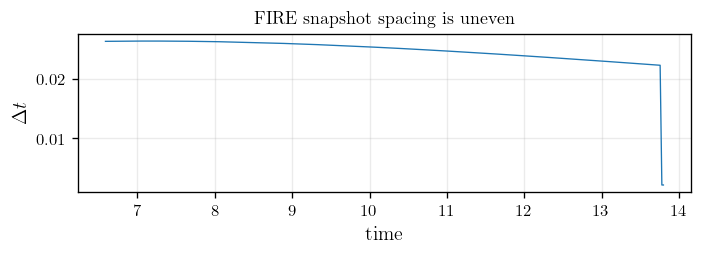

In [3]:
# The FIRE snapshot cadence is NOT uniform -- worth knowing before any time interpolation.
dt = np.diff(mser.times)
print(f"dt: min={dt.min():.5f} max={dt.max():.5f}  (ratio {dt.max()/dt.min():.1f}x)")

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.plot(mser.times[:-1], dt, lw=0.8)
ax.set_xlabel("time"); ax.set_ylabel(r"$\Delta t$"); ax.set_title("FIRE snapshot spacing is uneven")
plt.tight_layout(); plt.show()

### A single-group read is unchanged

This is the backward-compatibility guarantee: reading one group returns exactly what it
always did, with `times is None`, and it must equal the corresponding slice of the series.

In [4]:
m0 = ah.read_coefs(MULT_H5, group_name="snap_300")
print("single read -> times is None:", m0.times is None, "| phi.ndim:", m0.phi.ndim)
print("equals series slice 0 exactly:",
      np.array_equal(m0.phi, mser.phi[..., 0]),
      np.array_equal(m0.dphi_dr, mser.dphi_dr[..., 0]))

# snapshot(i) / [i] give a time-less view back
snap = mser.snapshot(0)
print("snapshot(0) == single read:", np.array_equal(snap.phi, m0.phi),
      "| mser[0] is equivalent:", np.array_equal(mser[0].phi, snap.phi))

single read -> times is None: True | phi.ndim: 2
equals series slice 0 exactly: True True
snapshot(0) == single read: True | mser[0] is equivalent: True


## 3. Round-trips: string, HDF5, Evolving `.ini`

In [5]:
# --- coef string -> re-read
for label, ser in (("Multipole", mser), ("CylSpline", cser)):
    rt = ah.read_coefs(ser.to_coef_string(t=150))
    if isinstance(ser, MultipoleCoefs):
        ok = np.allclose(rt.phi, ser.phi[..., 150], rtol=1e-12)
    else:
        ok = all(np.allclose(rt.phi[m], ser.phi[m][..., 150], rtol=1e-12) for m in ser.m_values)
    print(f"{label:10s} string round-trip at t-index 150: {ok}")

# NOTE: the text format writes %.13g (Multipole) / %.14g (CylSpline), so a
# value -> text -> value round-trip loses roughly the last digit (~1e-13 relative).

Multipole  string round-trip at t-index 150: True
CylSpline  string round-trip at t-index 150: True


In [6]:
# --- HDF5 -> read_coefs(group_name="all")
h5_out = WORK / "mult_roundtrip.h5"
h5_out.unlink(missing_ok=True)            # to_h5 APPENDS to an existing archive
t0 = time.time(); mser.to_h5(h5_out); t1 = time.time()
back = ah.read_coefs(h5_out, group_name="all")
print(f"h5 write {t1-t0:.1f}s | values match: {np.allclose(back.phi, mser.phi, rtol=1e-12)}"
      f" | times match: {np.allclose(back.times, mser.times)}")

# --- Evolving .ini (writes one coef file per time, then the config)
ini = mser.to_evolving_ini(WORK / "mult_series.ini", out_dir=WORK / "mult_coefs")
back_ini = ah.read_coefs(ini)             # times come from the .ini timestamps
print("ini round-trip:", back_ini.phi.shape, "| times match:",
      np.allclose(back_ini.times, mser.times))

h5 write 0.3s | values match: True | times match: True


ini round-trip: (25, 25, 301) | times match: True


In [7]:
# --- explicit group selection: subsetting and reordering both keep the right time
sel  = ["snap_450", "snap_300", "snap_600"]
some = ah.read_coefs(MULT_H5, group_name=sel)
print("requested:", sel)
print("times    :", some.times)
print("each matches the full series at the same group:",
      all(np.array_equal(some.snapshot(j).phi,
                         mser.snapshot(list(mser.times).index(some.times[j])).phi)
          for j in range(len(sel))))

requested: ['snap_450', 'snap_300', 'snap_600']
times    : [10.46817917  6.58906279 13.79874688]
each matches the full series at the same group: True


## 4. Materializing, and the GPU fast path

`materialize_potential()` serialises from the **live** arrays, so any manual surgery you
do on `phi` is picked up automatically.

- no time axis -> `load_agama_potential`
- time axis -> `load_agama_evolving_potential(times=self.times)`

With `gpu=True` and a coefficient object, the arrays go **straight** to the GPU builders
instead of being round-tripped through text. That is precision-preserving, not just
faster: the text format is written at `%.13g` / `%.14g`, which truncates float64.

In [8]:
xyz = np.array([[8.0, 0.0, 0.0], [3.0, 2.0, 1.0], [15.0, -6.0, 3.0]])

t0 = time.time(); pot_cpu = mser.materialize_potential();          t1 = time.time()
pot_gpu = mser.materialize_potential(gpu=True);                    t2 = time.time()
print(f"CPU (agama Evolving) built in {t1-t0:.1f}s | GPU built in {t2-t1:.1f}s")

for t in (7.0, 10.0, 13.0):
    a, b = to_np(pot_cpu.potential(xyz, t=t)), to_np(pot_gpu.potential(xyz, t=t))
    print(f"  t={t:5.2f}  Phi_cpu={a[0]:12.2f}  GPU vs CPU rel = {np.max(np.abs(b-a)/np.abs(a)):.2e}")

CPU (agama Evolving) built in 0.5s | GPU built in 0.9s


  t= 7.00  Phi_cpu=   -95231.65  GPU vs CPU rel = 1.47e-07
  t=10.00  Phi_cpu=   -98197.77  GPU vs CPU rel = 5.53e-08
  t=13.00  Phi_cpu=  -102920.92  GPU vs CPU rel = 1.00e-07


In [9]:
# Is the fast path actually taken? Count the text round-trips it is supposed to avoid.
from nbody_streams.agama_helper import _coefs as _C

calls = {"read_coefs": 0, "to_coef_string": 0}
_orig_rc, _orig_ts = _C.read_coefs, _C.MultipoleCoefs.to_coef_string
_C.read_coefs = lambda *a, **k: (calls.__setitem__("read_coefs", calls["read_coefs"]+1), _orig_rc(*a, **k))[1]
_C.MultipoleCoefs.to_coef_string = lambda self, *a, **k: (calls.__setitem__("to_coef_string", calls["to_coef_string"]+1), _orig_ts(self, *a, **k))[1]
try:
    _ = mser.materialize_potential(gpu=True)
    print("coef object -> GPU :", calls, "-> fast path active:",
          calls["read_coefs"] == 0 and calls["to_coef_string"] == 0)

    calls.update(read_coefs=0, to_coef_string=0)
    _ = ah.load_agama_evolving_potential(mser.to_coef_strings(), times=mser.times, gpu=True)
    print("coef strings -> GPU:", calls, "(parses every snapshot, as expected)")
finally:
    _C.read_coefs, _C.MultipoleCoefs.to_coef_string = _orig_rc, _orig_ts

coef object -> GPU : {'read_coefs': 0, 'to_coef_string': 0} -> fast path active: True


coef strings -> GPU: {'read_coefs': 301, 'to_coef_string': 301} (parses every snapshot, as expected)


In [10]:
# Cross-device consistency. The two GPU builds differ only by the text truncation the
# fast path avoids; the GPU-vs-agama gap is the known BFE reconstruction floor.
pot_gpu_str = ah.load_agama_evolving_potential(mser.to_coef_strings(), times=mser.times, gpu=True)
for t in (7.0, 10.0, 13.0):
    a = to_np(pot_cpu.potential(xyz, t=t))
    b = to_np(pot_gpu.potential(xyz, t=t))
    c = to_np(pot_gpu_str.potential(xyz, t=t))
    print(f"t={t:5.2f} | GPU_fast vs GPU_string = {np.max(np.abs(b-c)/np.abs(c)):.2e}"
          f" (text truncation) | GPU vs agama CPU = {np.max(np.abs(b-a)/np.abs(a)):.2e}")

t= 7.00 | GPU_fast vs GPU_string = 1.54e-14 (text truncation) | GPU vs agama CPU = 1.47e-07
t=10.00 | GPU_fast vs GPU_string = 3.13e-13 (text truncation) | GPU vs agama CPU = 5.53e-08
t=13.00 | GPU_fast vs GPU_string = 2.67e-13 (text truncation) | GPU vs agama CPU = 1.00e-07


## 5. Manipulation: zeroing harmonics across the whole series

`zeroed` works with or without a time axis and keeps the time labels. Direct field
assignment is also legal — `validate()` is what catches the damage, and it runs
automatically at the top of every write and materialize entry point.

In [11]:
mono = mser.zeroed([0])              # keep l=0 only
quad = mser.zeroed([0, 2])           # monopole + quadrupole

c00 = mser.column(0, 0)              # index of (l=0, m=0) in lm_labels
c20 = mser.column(2, 0)
print("kept   l=0 column untouched:", np.array_equal(mono.phi[:, c00, :], mser.phi[:, c00, :]))
print("zeroed l=2 column at every time:", np.all(mono.phi[:, c20, :] == 0.0))
print("time axis survives:", mono.n_times, "| times shared with parent?", mono.times is mser.times)

pot_mono = mono.materialize_potential()
for t in (7.0, 10.0, 13.0):
    full = to_np(pot_cpu.potential(xyz, t=t))[0]
    m0   = to_np(pot_mono.potential(xyz, t=t))[0]
    print(f"  t={t:5.2f}  full={full:11.2f}  l=0 only={m0:11.2f}  ({abs((m0-full)/full):.2%} apart)")

kept   l=0 column untouched: True
zeroed l=2 column at every time: True
time axis survives: 301 | times shared with parent? False


  t= 7.00  full=  -95231.65  l=0 only=  -93068.37  (2.27% apart)
  t=10.00  full=  -98197.77  l=0 only=  -97997.96  (0.20% apart)
  t=13.00  full= -102920.92  l=0 only= -102776.29  (0.14% apart)


In [12]:
# validate() catches damage from direct assignment, naming the field and both shapes
damaged = mser.copy()
damaged.phi = damaged.phi[:, :-1, :]     # drop an (l, m) column but not its label
try:
    damaged.to_coef_string(t=0)          # a write entry point -> validate() runs first
except ValueError as e:
    print("ValueError:", e)

ValueError: MultipoleCoefs.phi has shape (25, 24, 301), expected (25, 25, 301) (len(R_grid)=25, len(lm_labels)=25, len(times)=301).


## 6. The monopole coefficient over time

`phi[:, column(0,0), :]` is the `(l=0, m=0)` coefficient at every radial node and every
time — shape `(nR, nt)`. This is the quantity a resampling scheme has to reproduce.

monopole block: (25, 301)


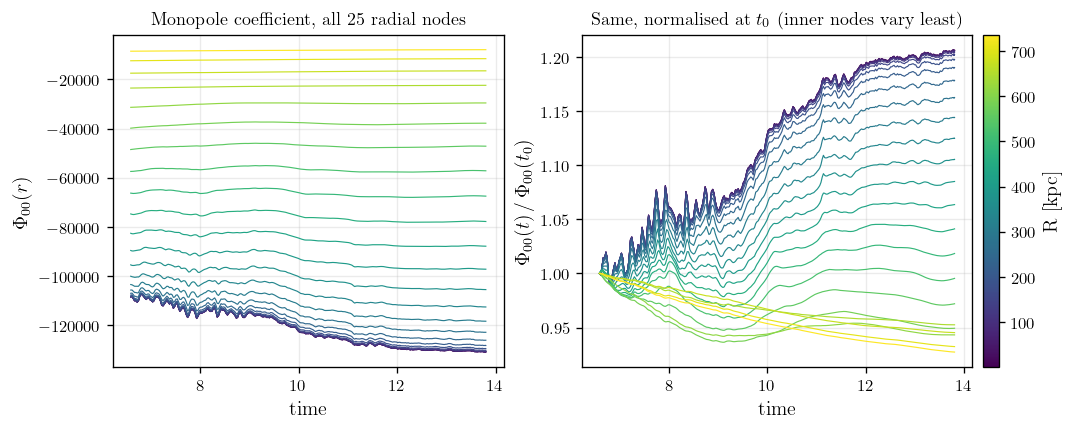

In [13]:
mono_series = mser.phi[:, mser.column(0, 0), :]      # (nR, nt)
print("monopole block:", mono_series.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
cmap = plt.cm.viridis(np.linspace(0, 1, len(mser.R_grid)))

for i, R in enumerate(mser.R_grid):
    axes[0].plot(mser.times, mono_series[i], color=cmap[i], lw=0.7)
axes[0].set_xlabel("time"); axes[0].set_ylabel(r"$\Phi_{00}(r)$")
axes[0].set_title(f"Monopole coefficient, all {len(mser.R_grid)} radial nodes")

# normalise each node by its own initial value to compare shapes across radii
for i in range(len(mser.R_grid)):
    axes[1].plot(mser.times, mono_series[i] / mono_series[i, 0], color=cmap[i], lw=0.7)
axes[1].set_xlabel("time"); axes[1].set_ylabel(r"$\Phi_{00}(t)\,/\,\Phi_{00}(t_0)$")
axes[1].set_title("Same, normalised at $t_0$ (inner nodes vary least)")

sm = plt.cm.ScalarMappable(cmap="viridis",
                           norm=plt.Normalize(mser.R_grid.min(), mser.R_grid.max()))
fig.colorbar(sm, ax=axes, label="R [kpc]", pad=0.01)
plt.show()

## 7. A cubic-spline time-resampling wrapper

The package deliberately ships no interpolation. Here is the user-side half: build an
`agama.Spline` per coefficient series, sample it on a finer grid, and hand the result back
with `with_times`.

Two details worth getting right:

1. **Refine each interval**, don't `linspace` the whole range. The FIRE cadence is uneven,
   so a global `linspace` would not contain the original nodes and you could not check
   node preservation.
2. **Spline the derivative block too.** Agama cannot load a Multipole file without a
   `#dPhi/dr` section, and `with_times` refuses to silently drop a `dphi_dr` it cannot
   reconcile with the new time axis.

In [14]:
# Both helpers ship with the package:
#     from nbody_streams.agama_helper import refine_times, spline_resample_coefs
# They are reproduced here so the mechanism is visible -- this is all it takes.

def refine_times(times, factor=10):
    '''
    Subdivide every interval of *times* by *factor*.

    The original nodes are preserved exactly and land at indices ``0, factor, 2*factor,
    ...``, which is what makes node preservation checkable. Returns
    ``factor * (nt - 1) + 1`` samples.
    '''
    times = np.asarray(times, dtype=float)
    pieces = [np.linspace(times[i], times[i + 1], factor + 1)[:-1]
              for i in range(len(times) - 1)]
    return np.concatenate(pieces + [times[-1:]])


def _spline_block(block, times, times_new):
    '''Cubic-spline every coefficient series along the trailing time axis.'''
    lead, nt = block.shape[:-1], block.shape[-1]
    flat = np.asarray(block, dtype=float).reshape(-1, nt)
    out = np.empty((flat.shape[0], len(times_new)), dtype=float)
    for k in range(flat.shape[0]):
        out[k] = agama.Spline(times, flat[k])(times_new)
    return out.reshape(lead + (len(times_new),))


def spline_resample(coefs, times_new):
    '''
    Resample a coefficient time series onto *times_new* with cubic splines.

    Works for both expansion types. Every coefficient -- including the derivative
    blocks -- gets its own ``agama.Spline`` along time. Grids and labels are untouched:
    only the trailing time axis changes.

    Parameters
    ----------
    coefs : MultipoleCoefs or CylSplineCoefs
        Must already carry a time axis.
    times_new : array-like
        New sample times. Any length; need not contain the original nodes.

    Returns
    -------
    MultipoleCoefs or CylSplineCoefs
        A new object with ``n_times == len(times_new)``.
    '''
    if not coefs.has_time_axis:
        raise ValueError("spline_resample needs a coefficient object with a time axis.")
    times = np.asarray(coefs.times, dtype=float)
    times_new = np.asarray(times_new, dtype=float)

    if isinstance(coefs, MultipoleCoefs):
        return coefs.with_times(
            times_new,
            phi=_spline_block(coefs.phi, times, times_new),
            dphi_dr=(None if coefs.dphi_dr is None
                     else _spline_block(coefs.dphi_dr, times, times_new)),
        )

    extra = {name: {m: _spline_block(v, times, times_new) for m, v in tabs.items()}
             for name in ("dphi_dR", "dphi_dz")
             if (tabs := getattr(coefs, name)) is not None}
    return coefs.with_times(
        times_new,
        phi={m: _spline_block(v, times, times_new) for m, v in coefs.phi.items()},
        **extra,
    )

In [15]:
FACTOR = 10
t_fine = refine_times(mser.times, FACTOR)
print(f"time grid: {mser.n_times} -> {len(t_fine)} samples ({FACTOR}x)")

t0 = time.time(); mfine = spline_resample(mser, t_fine); t1 = time.time()
print(f"Multipole resampled in {t1-t0:.1f}s -> phi{mfine.phi.shape}")

mfine.validate()
print("original nodes preserved exactly (phi)    :",
      np.allclose(mfine.phi[..., ::FACTOR], mser.phi, rtol=1e-12))
print("original nodes preserved exactly (dphi_dr):",
      np.allclose(mfine.dphi_dr[..., ::FACTOR], mser.dphi_dr, rtol=1e-12))
print("times at nodes match                      :",
      np.allclose(t_fine[::FACTOR], mser.times))

time grid: 301 -> 3001 samples (10x)
Multipole resampled in 0.1s -> phi(25, 25, 3001)
original nodes preserved exactly (phi)    : True
original nodes preserved exactly (dphi_dr): True
times at nodes match                      : True


### Original vs resampled

The spline passes through every original node and fills in the curvature that straight
linear-in-time interpolation would miss. The second row zooms into the region where the
snapshot cadence is coarsest, which is where the difference is largest.

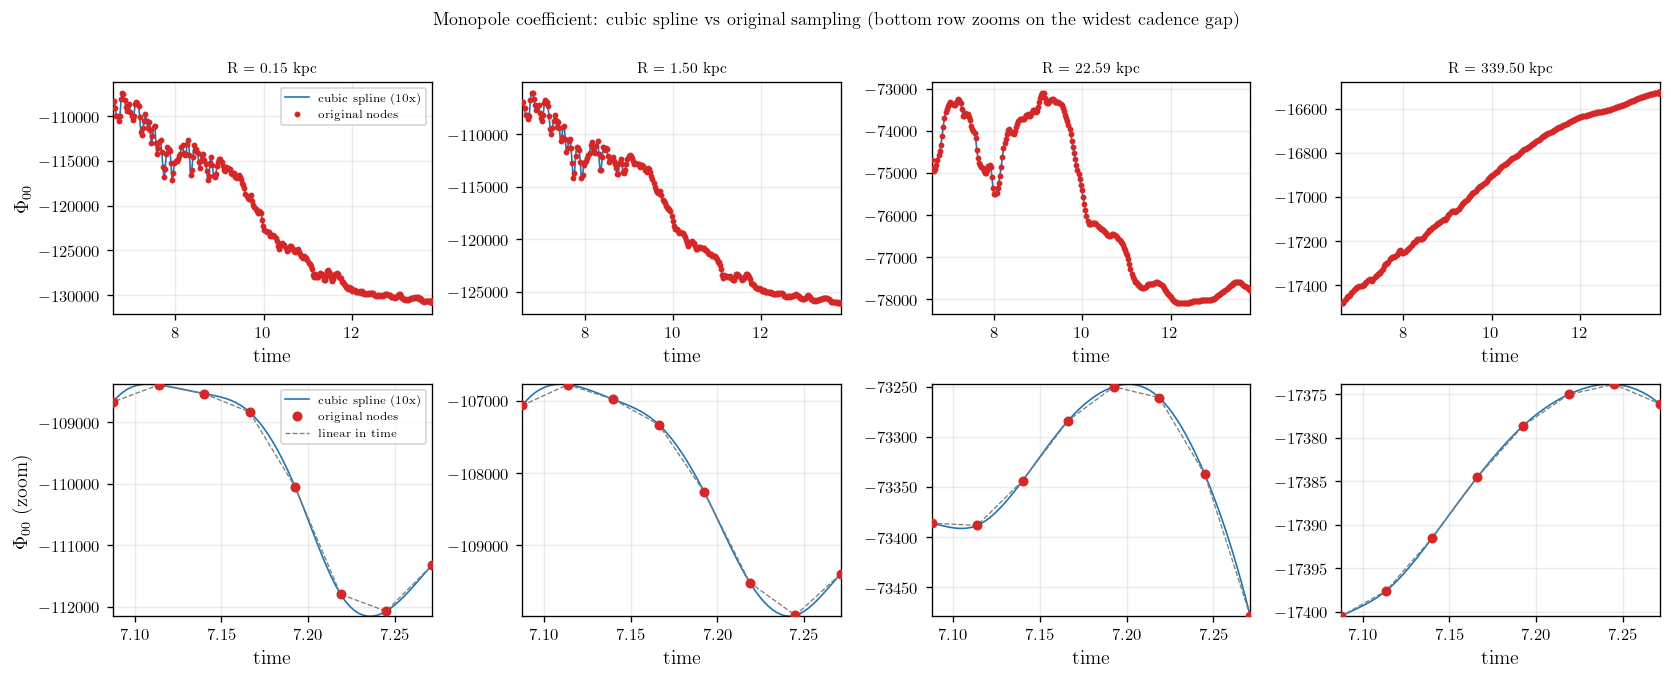

In [16]:
c00 = mser.column(0, 0)
node_idx = [2, 8, 15, 22]              # a few radial nodes

fig, axes = plt.subplots(2, len(node_idx), figsize=(14, 5.6))
# widest-gap region: where the original sampling is sparsest
gap = np.argmax(np.diff(mser.times))
lo, hi = mser.times[max(gap-3, 0)], mser.times[min(gap+4, len(mser.times)-1)]

for col, i in enumerate(node_idx):
    y_orig, y_fine = mser.phi[i, c00, :], mfine.phi[i, c00, :]
    for row, (x0, x1) in enumerate([(mser.times[0], mser.times[-1]), (lo, hi)]):
        ax = axes[row, col]
        ax.plot(t_fine, y_fine, "-",  lw=1.0, color="C0", label=f"cubic spline ({FACTOR}x)")
        ax.plot(mser.times, y_orig, "o", ms=2.5 if row == 0 else 5,
                color="C3", label="original nodes", zorder=3)
        if row == 1:
            ax.plot(mser.times, y_orig, "--", lw=0.8, color="C7", label="linear in time")
        ax.set_xlim(x0, x1)
        if row == 1:
            m = (t_fine >= x0) & (t_fine <= x1)
            ax.set_ylim(y_fine[m].min(), y_fine[m].max())
        if row == 0:
            ax.set_title(f"R = {mser.R_grid[i]:.2f} kpc", fontsize=9)
        if col == 0:
            ax.set_ylabel([r"$\Phi_{00}$", r"$\Phi_{00}$ (zoom)"][row])
        ax.set_xlabel("time")

axes[0, 0].legend(fontsize=7)
axes[1, 0].legend(fontsize=7)
fig.suptitle("Monopole coefficient: cubic spline vs original sampling "
             "(bottom row zooms on the widest cadence gap)", y=1.0)
plt.tight_layout(); plt.show()

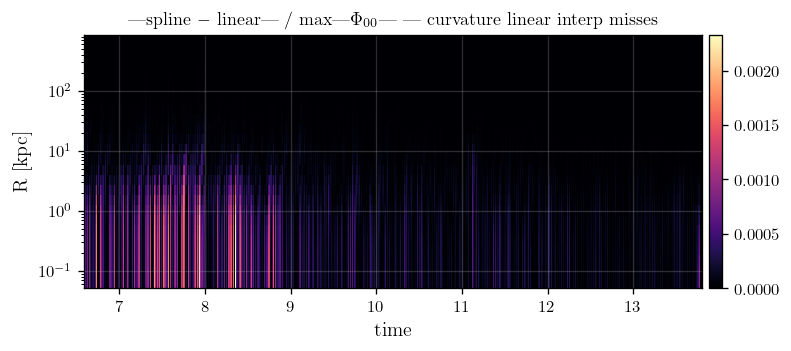

peak relative departure from linear: 2.33e-03


In [17]:
# How far does the spline depart from linear-in-time between nodes?
lin = np.empty_like(mfine.phi[:, c00, :])
for i in range(len(mser.R_grid)):
    lin[i] = np.interp(t_fine, mser.times, mser.phi[i, c00, :])
dev = np.abs(mfine.phi[:, c00, :] - lin) / np.abs(mser.phi[:, c00, :]).max()

fig, ax = plt.subplots(figsize=(7, 3))
im = ax.pcolormesh(t_fine, mser.R_grid, dev, shading="auto", cmap="magma")
ax.set_yscale("log"); ax.set_xlabel("time"); ax.set_ylabel("R [kpc]")
ax.set_title(r"|spline $-$ linear| / max|$\Phi_{00}$| — curvature linear interp misses")
fig.colorbar(im, ax=ax, pad=0.01); plt.tight_layout(); plt.show()
print(f"peak relative departure from linear: {dev.max():.2e}")

### The resampled series is a first-class object: materialize it

Read the table below carefully. **Between** the original nodes the two potentials
genuinely differ: Agama interpolates the 301-node series linearly in time, while the
3001-node series already has the spline's curvature baked in. That gap *is* the curvature
linear interpolation was missing -- it is the point of the exercise, not an error.

**At** an original node both must agree to round-off, since the spline passes through
every node. That is the check that would catch a broken resampling.

In [18]:
pot_fine = mfine.materialize_potential()
print("materialized the 10x series\n")
print("BETWEEN nodes -- the two disagree by the curvature linear interp misses:")
print(f"{'time':>8} {'orig (301)':>14} {'spline (3001)':>15} {'rel diff':>10}")
for t in (7.0, 8.5, 10.0, 11.5, 13.0):
    a = to_np(pot_cpu.potential(xyz, t=t))[0]
    b = to_np(pot_fine.potential(xyz, t=t))[0]
    print(f"{t:8.3f} {a:14.2f} {b:15.2f} {abs((b-a)/a):10.2e}")

print("\nAT original nodes -- the spline passes through them, so these must agree:")
print(f"{'time':>8} {'orig (301)':>14} {'spline (3001)':>15} {'rel diff':>10}")
for k in (0, 75, 150, 225, 300):
    t = float(mser.times[k])
    a = to_np(pot_cpu.potential(xyz, t=t))[0]
    b = to_np(pot_fine.potential(xyz, t=t))[0]
    print(f"{t:8.3f} {a:14.2f} {b:15.2f} {abs((b-a)/a):10.2e}")

# It also works on the GPU, through the same fast path
pot_fine_gpu = mfine.materialize_potential(gpu=True)
print("\nGPU:", float(to_np(pot_fine_gpu.potential(xyz, t=10.0))[0]))

materialized the 10x series

BETWEEN nodes -- the two disagree by the curvature linear interp misses:
    time     orig (301)   spline (3001)   rel diff
   7.000      -95231.65       -95258.48   2.82e-04
   8.500      -94802.53       -94801.34   1.25e-05
  10.000      -98197.77       -98192.19   5.68e-05
  11.500     -101668.45      -101665.57   2.84e-05
  13.000     -102920.92      -102925.51   4.46e-05

AT original nodes -- the spline passes through them, so these must agree:
    time     orig (301)   spline (3001)   rel diff
   6.589      -94152.99       -94152.99   0.00e+00
   8.553      -94431.62       -94431.62   0.00e+00
  10.468     -100238.72      -100238.72   0.00e+00
  12.289     -103846.45      -103846.45   0.00e+00
  13.799     -104038.65      -104038.65   0.00e+00



GPU: -98192.18819999669


## 8. The same for CylSpline

`spline_resample` dispatches on the class, so the bar potential needs no extra code.
These files are `#Phi`-only, so there are no derivative tables to spline.

In [19]:
t_fine_c = refine_times(cser.times, FACTOR)
t0 = time.time(); cfine = spline_resample(cser, t_fine_c); t1 = time.time()
print(f"CylSpline resampled in {t1-t0:.1f}s -> phi[0]{cfine.phi[0].shape}")
cfine.validate()
print("nodes preserved:", all(np.allclose(cfine.phi[m][..., ::FACTOR], cser.phi[m], rtol=1e-12)
                              for m in cser.m_values))

xyz_bar = np.array([[8.0, 0.0, 0.2], [3.0, 2.0, 1.0], [5.0, -2.0, 0.5]])
pot_c      = cser.materialize_potential()
pot_c_fine = cfine.materialize_potential()
for t in (7.0, 10.0, 13.0):
    a = to_np(pot_c.potential(xyz_bar, t=t))[0]
    b = to_np(pot_c_fine.potential(xyz_bar, t=t))[0]
    print(f"  t={t:5.2f}  orig={a:11.3f}  spline={b:11.3f}  rel={abs((b-a)/a):.2e}")

CylSpline resampled in 0.9s -> phi[0](25, 49, 3001)
nodes preserved: True


  t= 7.00  orig= -25574.414  spline= -25680.859  rel=4.16e-03
  t=10.00  orig= -34817.808  spline= -34784.853  rel=9.46e-04
  t=13.00  orig= -45353.194  spline= -45172.279  rel=3.99e-03


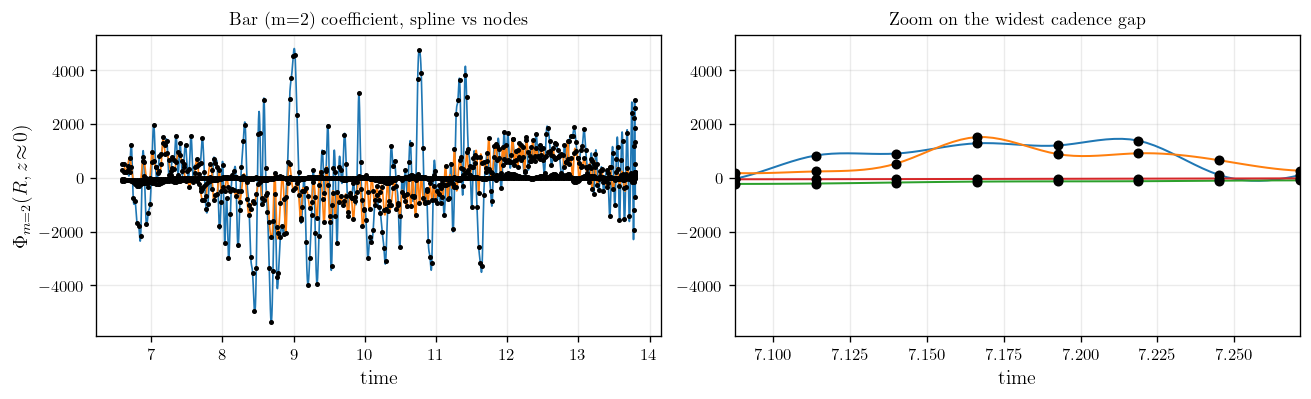

In [20]:
# m=2 is the bar mode: plot its coefficient at the midplane vs time, a few radial nodes
iz = np.argmin(np.abs(cser.z_grid))          # midplane row
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for i in [4, 9, 14, 19]:
    axes[0].plot(t_fine_c, cfine.phi[2][i, iz, :], lw=1.0)
    axes[0].plot(cser.times, cser.phi[2][i, iz, :], "o", ms=2, color="k", zorder=3)
axes[0].set_xlabel("time"); axes[0].set_ylabel(r"$\Phi_{m=2}(R, z\!\approx\!0)$")
axes[0].set_title("Bar (m=2) coefficient, spline vs nodes")

gap = np.argmax(np.diff(cser.times))
lo, hi = cser.times[max(gap-3, 0)], cser.times[min(gap+4, len(cser.times)-1)]
for i in [4, 9, 14, 19]:
    axes[1].plot(t_fine_c, cfine.phi[2][i, iz, :], lw=1.2)
    axes[1].plot(cser.times, cser.phi[2][i, iz, :], "o", ms=5, color="k", zorder=3)
axes[1].set_xlim(lo, hi); axes[1].set_xlabel("time")
axes[1].set_title("Zoom on the widest cadence gap")
plt.tight_layout(); plt.show()

## 9. Round-tripping the resampled series back to disk

The resampled object writes exactly like any other: HDF5 (round-trips through
`read_coefs(group_name="all")`), one text file per time, or an Evolving `.ini`.

In [21]:
out = WORK / "mult_spline10x.h5"
out.unlink(missing_ok=True)
t0 = time.time(); mfine.to_h5(out); t1 = time.time()
reread = ah.read_coefs(out, group_name="all")
print(f"wrote {mfine.n_times} snapshots in {t1-t0:.1f}s ({out.stat().st_size/1e6:.0f} MB)")
print("re-read:", reread.phi.shape,
      "| values match:", np.allclose(reread.phi, mfine.phi, rtol=1e-12),
      "| times match:", np.allclose(reread.times, mfine.times))
print("\nloads straight into an evolving potential:",
      float(ah.load_agama_evolving_potential(out).potential(xyz, t=10.0)[0]))

wrote 3001 snapshots in 3.2s (69 MB)
re-read: (25, 25, 3001) | values match: True | times match: True



loads straight into an evolving potential: -98192.18687936348


In [22]:
import shutil
shutil.rmtree(WORK, ignore_errors=True)
print("removed scratch dir", WORK)

removed scratch dir /tmp/coef_timeaxis_cnr9jebv


## Summary

- One reader, one class: `read_coefs(..., group_name="all")` gives a time series;
  a plain `group_name` still gives exactly the single snapshot it always did.
- Time is the trailing axis. `snapshot(i)`, `zeroed`, `radial_power`, `total_power`
  all behave the same way with or without it.
- `validate()` runs at the top of every write and materialize entry point, so direct
  field surgery is safe to do and hard to get silently wrong.
- `materialize_potential()` serialises from the live arrays; with `gpu=True` on a coef
  object it skips the text round-trip entirely, which preserves full float64.
- Resampling in time is *yours* to define. `with_times` is the attach point —
  `spline_resample` above is roughly 30 lines and handles both expansion types.